In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.listdir('/content/drive/MyDrive')

['DISK1 (1)',
 'DISK1',
 'Classroom',
 'Lecture 1 -- Listening Skills.gdoc',
 'UNIT 3 - CEMENT & POP (1).gdoc',
 'IR.gdoc',
 'NewDoc07-23-202410.28.gdoc',
 'Screenshot 2024-09-23 232453.png',
 'Bubble Sort (3).gdoc',
 'Bubble Sort (2).gdoc',
 'Bubble Sort (1).gdoc',
 'Bubble Sort.gdoc',
 'Counting Sort.gdoc',
 'W1.gslides',
 'W7.L1.gslides',
 'WhatsApp Image 2024-11-22 at 4.21.57 PM.jpeg',
 'python-01.pdf',
 'python-02.pdf',
 'Colab Notebooks',
 'MYRESUME.may.docx',
 'Document from Vidhi Sharma',
 'Screenshot 2025-06-02 121603.png',
 'Screenshot 2025-06-02 121632.png',
 'Event Registration.gform',
 'Vidhi_RESUME.docx',
 'AI Framework for Sustainable Packaging Design and Material Optimization .pdf',
 'archive (2).zip',
 'archive (3).zip',
 'archive (1).zip',
 'Screenshot_2026-02-10-10-37-20-41_40deb401b9ffe8e1df2f1cc5ba480b12.jpg',
 'Screenshot 2026-02-17 120337.png',
 'Screenshot 2026-02-17 120357.png',
 'Satellite dataset.zip']

In [ ]:
!cp "/content/drive/MyDrive/Satellite dataset.zip" /content/

In [ ]:
import zipfile

with zipfile.ZipFile('/content/Satellite dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

In [ ]:
os.listdir('/content/')

['.config',
 'Satellite dataset.zip',
 'EuroSAT',
 'drive',
 'EuroSATallBands',
 'sample_data']

In [ ]:
import shutil
import random

In [ ]:
# paths
dataset_path = '/content/EuroSAT'
output_path = '/content/split_data'

train_path = os.path.join(output_path, 'train')
test_path = os.path.join(output_path, 'test')
val_path = os.path.join(output_path, 'val')

In [ ]:

for path in [train_path, test_path, val_path]:
    os.makedirs(path, exist_ok=True)


In [ ]:

classes = os.listdir(dataset_path)

In [ ]:
for cls in classes:
    cls_path = os.path.join(dataset_path, cls)

    if not os.path.isdir(cls_path):
        continue

    images = os.listdir(cls_path)

    random.shuffle(images)

    total = len(images)


    train_size = int(0.7 * total)
    test_size = int(0.2 * total)

    train_imgs = images[:train_size]
    test_imgs = images[train_size:train_size + test_size]
    val_imgs = images[train_size + test_size:]

    os.makedirs(os.path.join(train_path, cls), exist_ok=True)
    os.makedirs(os.path.join(test_path, cls), exist_ok=True)
    os.makedirs(os.path.join(val_path, cls), exist_ok=True)

    for img in train_imgs:
        shutil.copy(os.path.join(cls_path, img),
                    os.path.join(train_path, cls, img))

    for img in test_imgs:
        shutil.copy(os.path.join(cls_path, img),
                    os.path.join(test_path, cls, img))

    for img in val_imgs:
        shutil.copy(os.path.join(cls_path, img),
                    os.path.join(val_path, cls, img))

    print(f"{cls} done")

print("Dataset shuffled and split successfully ✅")

Forest done
Industrial done
PermanentCrop done
SeaLake done
Residential done
Highway done
Pasture done
AnnualCrop done
HerbaceousVegetation done
River done
Dataset shuffled and split successfully ✅


In [ ]:
folders = ['train', 'test', 'val']

for f in folders:
    os.rename(f'/content/split_data/{f}/River',
              f'/content/split_data/{f}/water_bodies')

In [ ]:
base_path = '/content/split_data'

for split in ['train', 'test', 'val']:
    total = 0
    split_path = os.path.join(base_path, split)

    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        if os.path.isdir(cls_path):
            total += len(os.listdir(cls_path))

    print(f"{split.upper()} total images: {total}")

TRAIN total images: 18900
TEST total images: 5400
VAL total images: 2700


In [ ]:
for split in ['train', 'test', 'val']:
    print(f"\n{split.upper()}:\n")

    split_path = f'/content/split_data/{split}'

    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)

        if os.path.isdir(cls_path):
            print(f"{cls}: {len(os.listdir(cls_path))}")


TRAIN:

Forest: 2100
Industrial: 1750
water_bodies: 1750
PermanentCrop: 1750
SeaLake: 2100
Residential: 2100
Highway: 1750
Pasture: 1400
AnnualCrop: 2100
HerbaceousVegetation: 2100

TEST:

Forest: 600
Industrial: 500
water_bodies: 500
PermanentCrop: 500
SeaLake: 600
Residential: 600
Highway: 500
Pasture: 400
AnnualCrop: 600
HerbaceousVegetation: 600

VAL:

Forest: 300
Industrial: 250
water_bodies: 250
PermanentCrop: 250
SeaLake: 300
Residential: 300
Highway: 250
Pasture: 200
AnnualCrop: 300
HerbaceousVegetation: 300


In [ ]:
total_images = 0

for split in ['train', 'test', 'val']:
    for cls in os.listdir(f'/content/split_data/{split}'):
        total_images += len(os.listdir(f'/content/split_data/{split}/{cls}'))

print("Total images after split:", total_images)

Total images after split: 27000


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (128,128)
BATCH_SIZE = 16

train_gen = ImageDataGenerator(rescale=1./255)

val_gen = ImageDataGenerator(rescale=1./255)

test_gen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_data = train_gen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_gen.flow_from_directory(
    val_path,

    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 18900 images belonging to 10 classes.
Found 2700 images belonging to 10 classes.
Found 5400 images belonging to 10 classes.


In [ ]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [ ]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: []


In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models

In [ ]:
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

# Freeze base model
base_model.trainable = False

# Custom head
x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(train_data.num_classes, activation='softmax')(x)

densenet_model = models.Model(inputs=base_model.input, outputs=output)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
densenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

densenet_history = densenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,          # keep small
    callbacks=[early_stop]
)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1182/1182 ━━━━━━━━━━━━━━━━━━━━ 831s 692ms/step - accuracy: 0.7536 - loss: 0.7745 - val_accuracy: 0.9074 - val_loss: 0.2484
Epoch 2/5
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 801s 678ms/step - accuracy: 0.8992 - loss: 0.3059 - val_accuracy: 0.9148 - val_loss: 0.2346
Epoch 3/5
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 852s 721ms/step - accuracy: 0.9132 - loss: 0.2550 - val_accuracy: 0.9174 - val_loss: 0.2369
Epoch 4/5
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 844s 714ms/step - accuracy: 0.9186 - loss: 0.2332 - val_accuracy: 0.9211 - val_loss: 0.2064
Epoch 5/5
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 827s 700ms/step - accuracy: 0.9278 - loss: 0.2103 - val_accuracy: 0.9252 - val_loss: 0.1918


In [ ]:
densenet_loss, densenet_acc = densenet_model.evaluate(test_data)
print("DenseNet Accuracy:", densenet_acc)

338/338 ━━━━━━━━━━━━━━━━━━━━ 213s 627ms/step - accuracy: 0.9346 - loss: 0.2103
DenseNet Accuracy: 0.9225925803184509


In [ ]:
densenet_model.save('densenet_model.keras')

Get Predictions


In [ ]:
import numpy as np

y_true = test_data.classes
y_pred_prob = densenet_model.predict(test_data)
y_pred = np.argmax(y_pred_prob, axis=1)

338/338 ━━━━━━━━━━━━━━━━━━━━ 224s 653ms/step


Import Required Metrics

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    mean_squared_error,
    mean_absolute_error,
    classification_report,
    confusion_matrix
)

Calculate Metrics

In [ ]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
kappa = cohen_kappa_score(y_true, y_pred)

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)

print("DenseNet Results:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Cohen Kappa:", kappa)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

DenseNet Results:
Accuracy: 0.9225925925925926
Precision: 0.9242076309694441
Recall: 0.9225925925925926
F1 Score: 0.9224537636200589
Cohen Kappa: 0.9138118002840866
MSE: 1.635
RMSE: 1.2786711852544421
MAE: 0.3194444444444444


Classification Report

In [ ]:
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.94      0.94       600
           1       0.93      0.98      0.96       600
           2       0.90      0.93      0.92       600
           3       0.79      0.88      0.83       500
           4       0.96      0.93      0.95       500
           5       0.95      0.88      0.91       400
           6       0.95      0.83      0.88       500
           7       0.94      0.99      0.96       600
           8       0.99      0.99      0.99       600
           9       0.87      0.83      0.85       500

    accuracy                           0.92      5400
   macro avg       0.92      0.92      0.92      5400
weighted avg       0.92      0.92      0.92      5400



Confusion Matrix

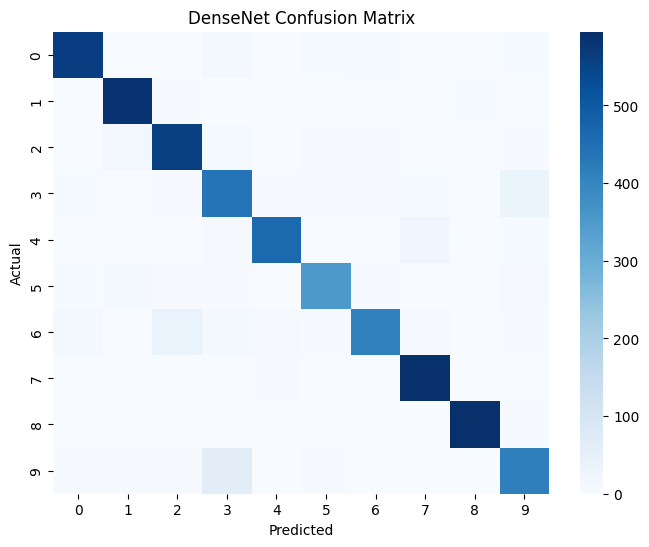

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DenseNet Confusion Matrix")
plt.show()

In [ ]:
densenet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 134, 134,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 32, 32,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 32, 32,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 32, 32,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 32, 32,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 32, 32,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 32, 32,    │     12,288 │ conv2_block2_0_r

 Total params: 7,832,416 (29.88 MB)

 Trainable params: 264,970 (1.01 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

 Optimizer params: 529,942 (2.02 MB)